## 1.Environment Setup

In [99]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler

# Đặt seed để đảm bảo nhất quán giữa các lần chạy
os.environ["PYTHONHASHSEED"] = "42"
np.random.seed(42)
random.seed(42)
print("Seed: 42")

Seed: 42


In [100]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


## 2.Data Processing

In [101]:
# # https://drive.google.com/file/d/16HPyuXWXPptt5g3xvS_kR_wXAfjpR1Ju/view?usp=sharing
# !gdown 16HPyuXWXPptt5g3xvS_kR_wXAfjpR1Ju

In [102]:
DATA_PATH = './Data/raw/cleveland.csv'
COLUMNS = ['age','sex','cp','trestbps','chol','fbs','restecg',
           'thalach','exang','oldpeak','slope','ca','thal','target']

raw = pd.read_csv(DATA_PATH)
raw.columns = COLUMNS

for c in ['age','trestbps','chol','thalach','oldpeak','ca','thal']:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')
# errors='coerce' — nếu gặp giá trị không convert được sang số thì thay bằng NaN thay vì báo lỗi

raw['target'] = (raw['target'] > 0).astype(int)
print("Shape:", raw.shape)
display(raw.head())
display(raw.isna().sum())

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [103]:
import pandas as pd

In [104]:
DATA_PATH = './Data/raw/cleveland.csv' 
COLUMNS = ['age','sex','cp','trestbps','chol','fbs','restecg',
           'thalach','exang','oldpeak','slope','ca','thal','target']

raw = pd.read_csv(DATA_PATH)
raw.columns=COLUMNS

In [105]:
raw.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [106]:
for c in ['age','trestbps','chol','thalach','oldpeak','ca','thal']:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')

In [107]:
raw.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [108]:
raw['target'] = (raw['target'] > 0).astype(int)

In [109]:
raw.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [110]:
# Define numerical, categorical columns before plotting
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [111]:
import matplotlib.pyplot as plt

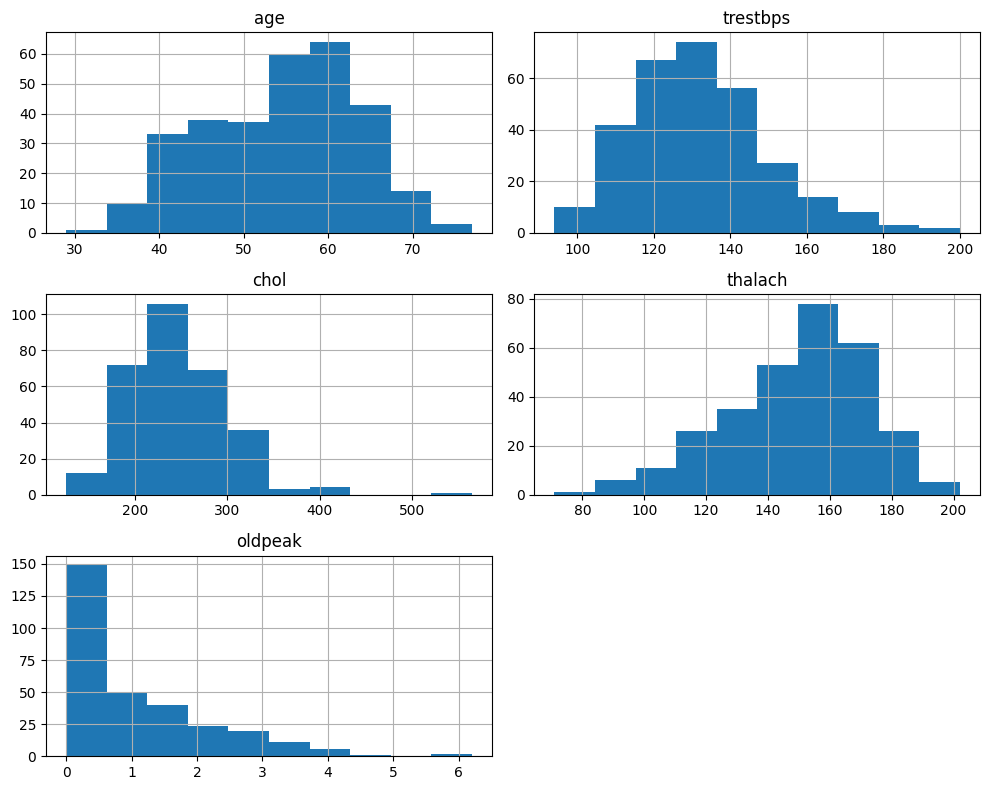

In [112]:
# Plot histograms for numerical columns
raw[numeric_cols].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

.unstack() Chuyển level cuối của MultiIndex (target) thành columns → từ Series thành DataFrame

ax=plt.gca() — vẽ lên axes hiện tại (gca = get current axes)

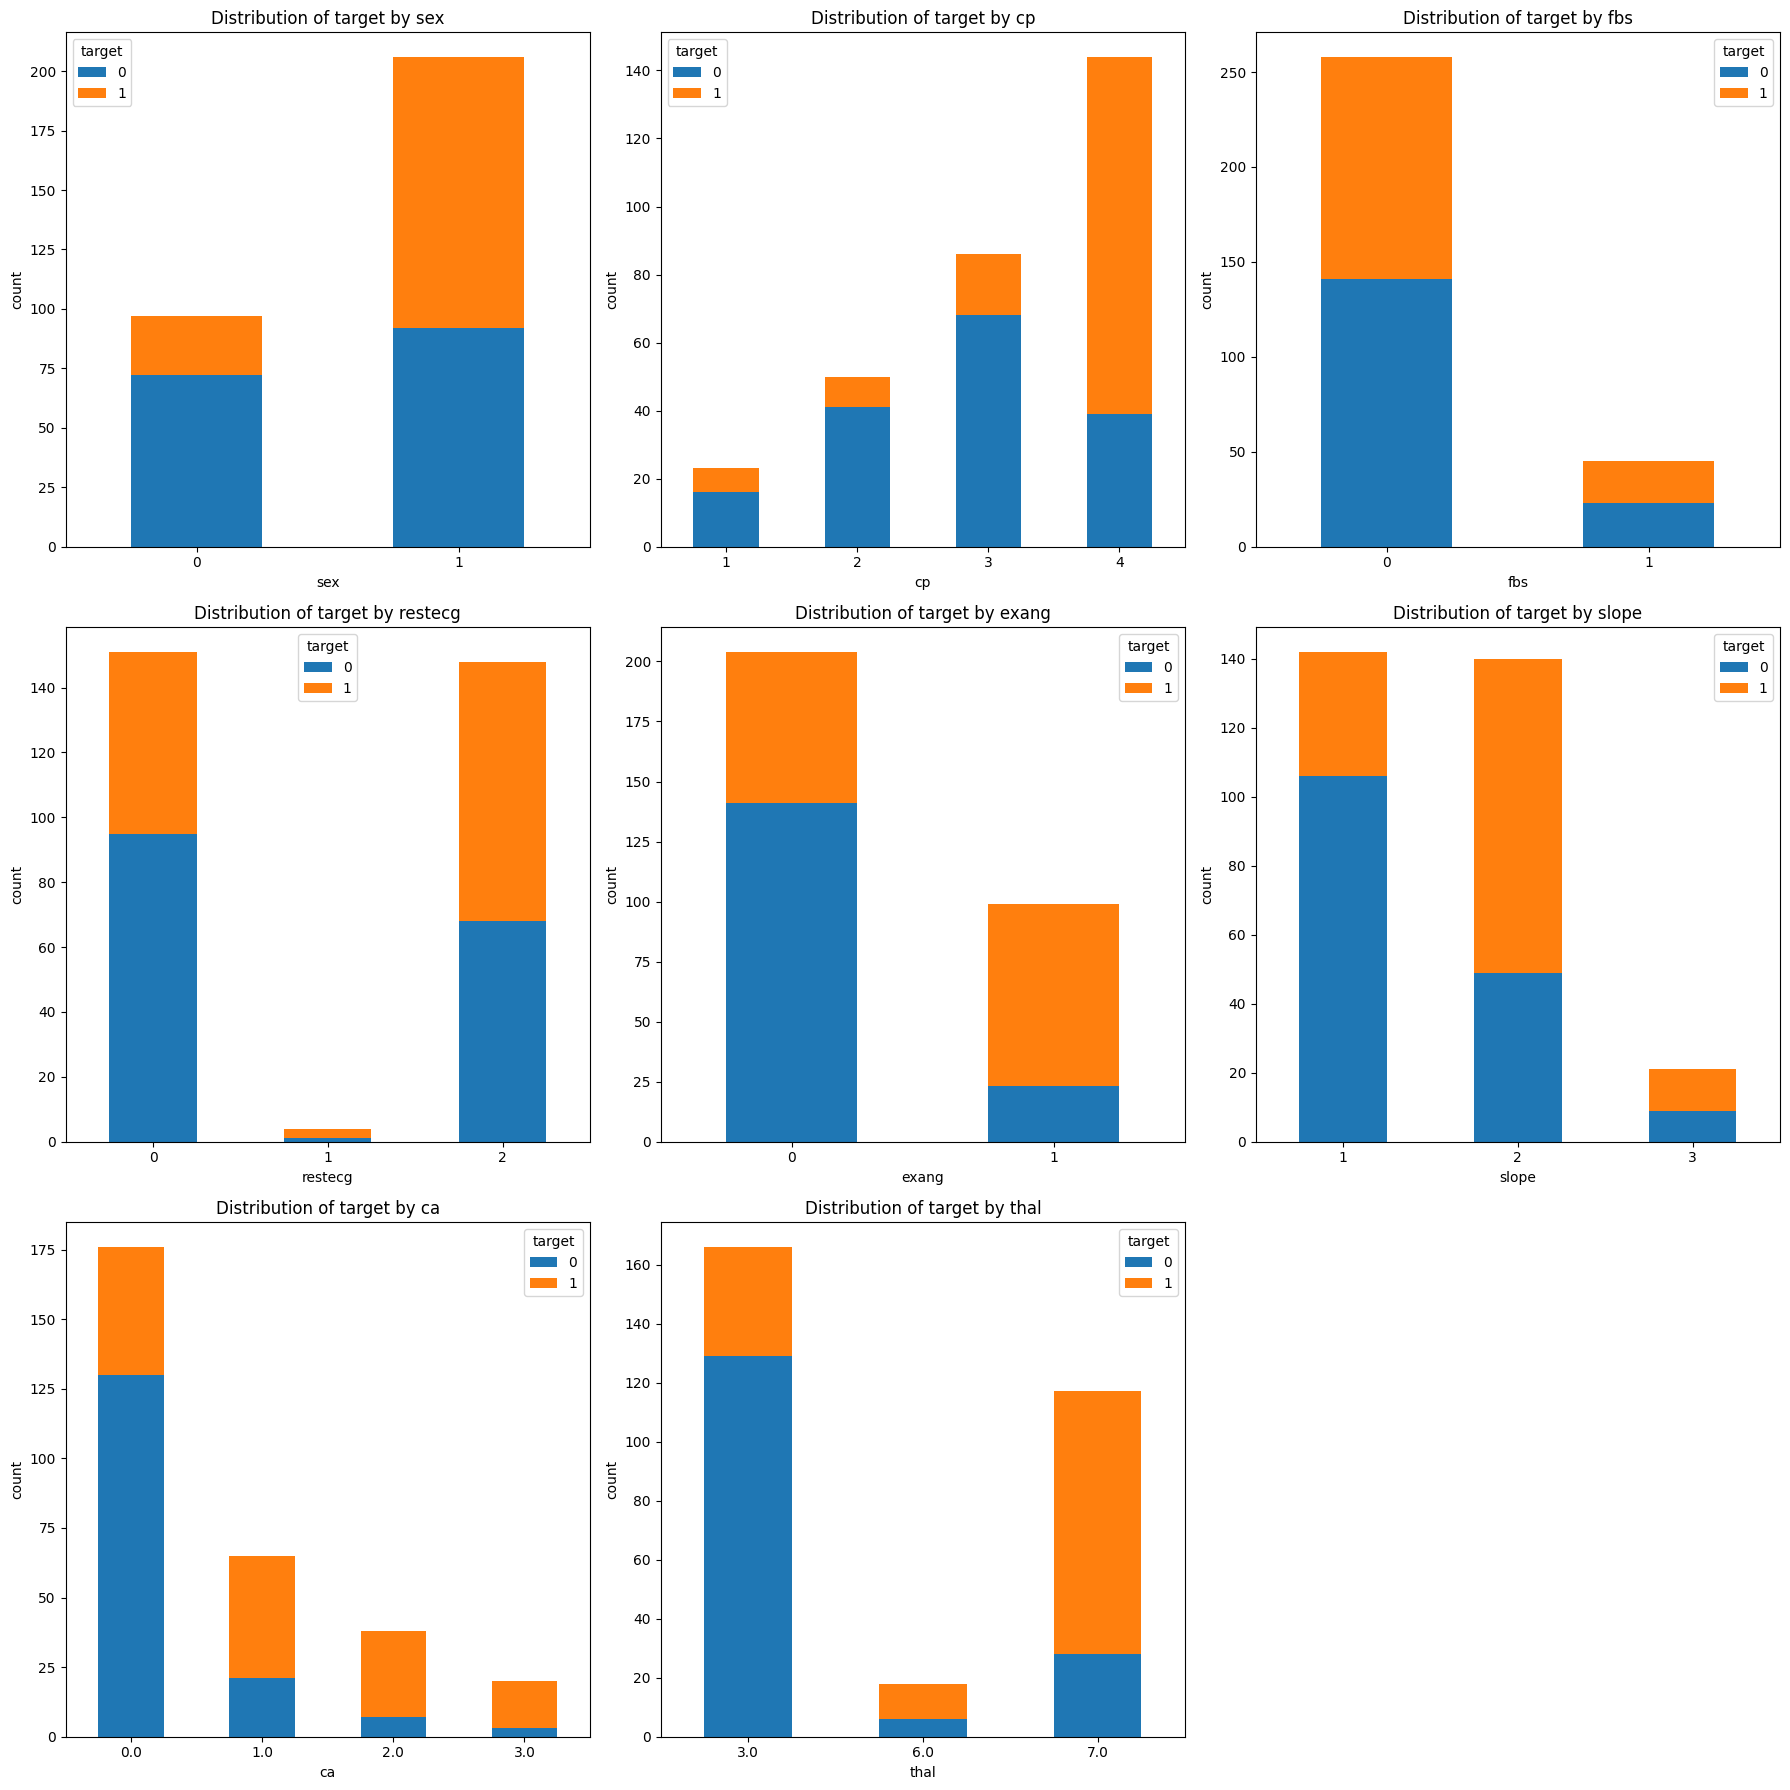

In [113]:
# Plot count plots for categorical columns
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    raw.groupby([col, 'target']).size().unstack().plot(
        kind='bar', stacked=True, ax=axes[i]
    )
    axes[i].set_title(f'Distribution of target by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')
    axes[i].tick_params(axis='x', rotation=0)

for j in range(len(categorical_cols), 9):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 3.Visual Explorations

In [114]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [115]:
X = raw.drop(columns=['target'])
y = raw['target']

In [116]:
y.unique()

array([0, 1])

In [117]:
# Colors ny target
colors = ['tab:blue' if t==0 else 'tab:red' for t in y]

x.reshape(-1, 1)   # -1 → tự tính = 4, kết quả (4, 1)

x.reshape(-1, 2)   # -1 → tự tính = 2, kết quả (2, 2)

x.reshape(2, -1)   # -1 → tự tính = 2, kết quả (2, 2)

In [118]:
def scatter_with_regression(x_series, y_series, x_label, y_label, title, ax=None):
    # Drop NaNs for fitting
    m = x_series.notna() & y_series.notna() # return Boolean (True/False)
    x = x_series[m].values.reshape(-1, 1)
    yy = y_series[m].values

    # Fit linear regression
    if len(x) > 1:
        model = LinearRegression()
        model.fit(x, yy)
        # Create line
        x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
        y_pred = model.predict(x_line)
    else:
        x_line, y_pred = None, None
    
    # Plot scatter
    if ax is None:
        fig, ax = plt.subplots()

    ax.scatter(x_series, y_series, color=colors, alpha=0.7)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)

    # Plot regression line
    if x_line is not None:
        ax.plot(x_line.ravel(), y_pred)

In [119]:
X.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')

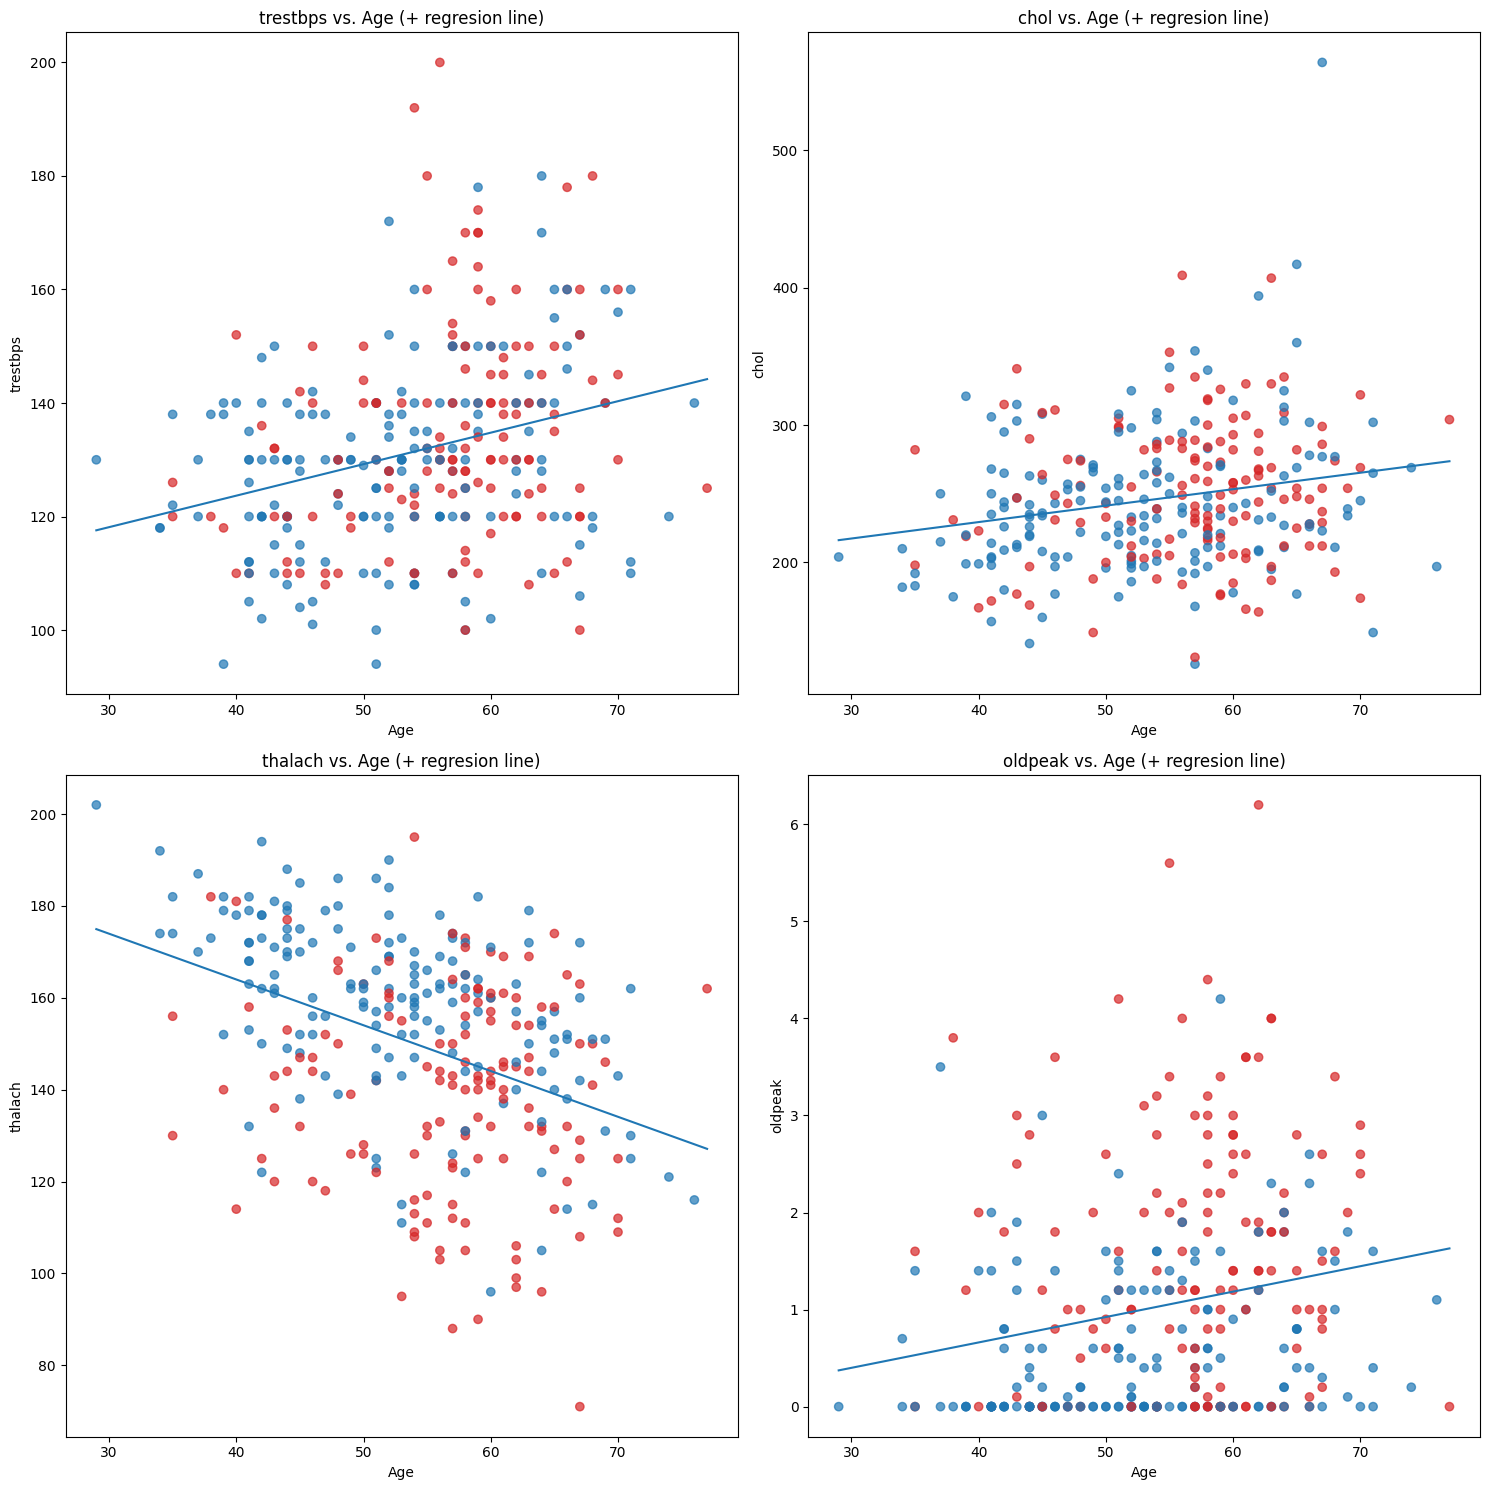

In [120]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten() #.flatten() chuyển về 1D shape (12,)

cols_to_plot = ['trestbps', 'chol','thalach', 'oldpeak']

for i, col in enumerate(cols_to_plot):
    scatter_with_regression(X['age'], X[col], 'Age', col, f'{col} vs. Age (+ regresion line)', ax=axes[i])

# for j in range(len(cols_to_plot), 12):
#     axes[j].set_visible(False)

plt.tight_layout()
plt.show()


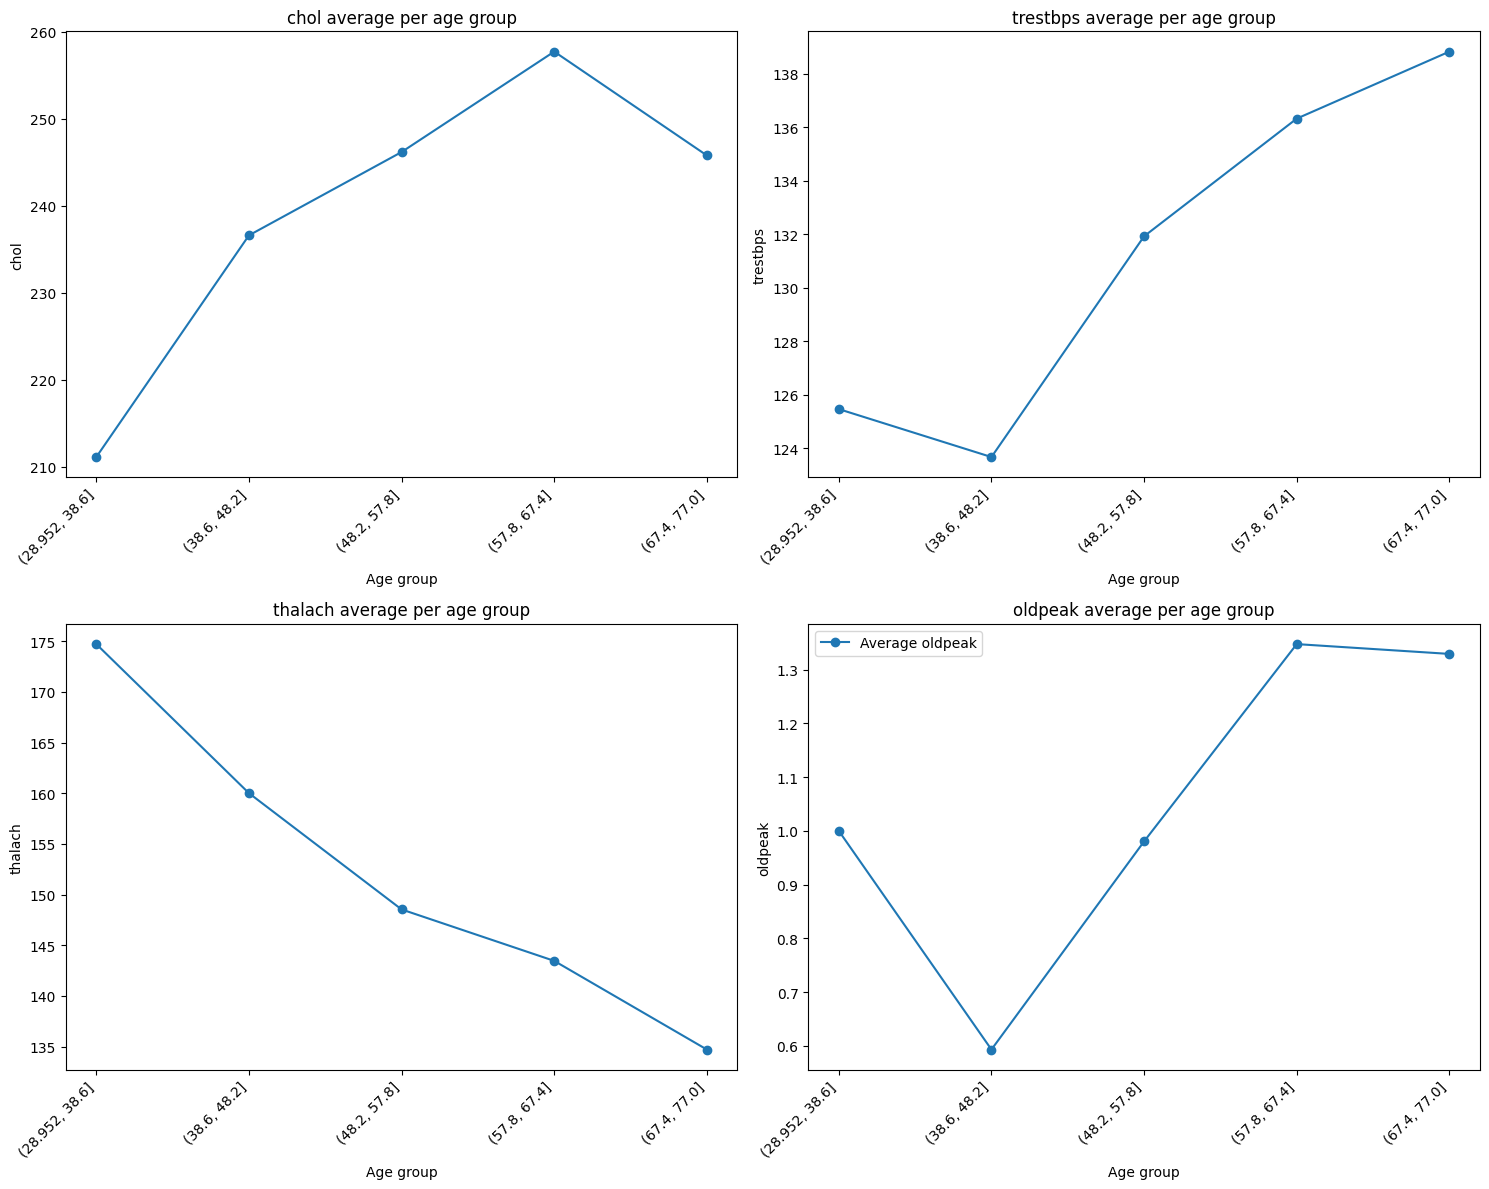

In [121]:
# Group means by age bins

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

age_bins = pd.cut(X['age'], bins=5)

for i, col in enumerate(['chol', 'trestbps', 'thalach', 'oldpeak']):
    avg_vals = X.groupby(age_bins)[col].mean()
    axes[i].plot(range(len(avg_vals)), avg_vals, marker='o', label=f'Average {col}')
    axes[i].set_xticks(range(len(avg_vals))) # đặt tick tại 0,1,2,3,4
    axes[i].set_xticklabels([str(j) for j in avg_vals.index], rotation=45, ha='right')
    # ha='right' — căn lề phải để không bị chồng nhau
    axes[i].set_xlabel('Age group')
    axes[i].set_ylabel(col)
    axes[i].set_title(f'{col} average per age group')

plt.legend()
plt.tight_layout()
plt.show()

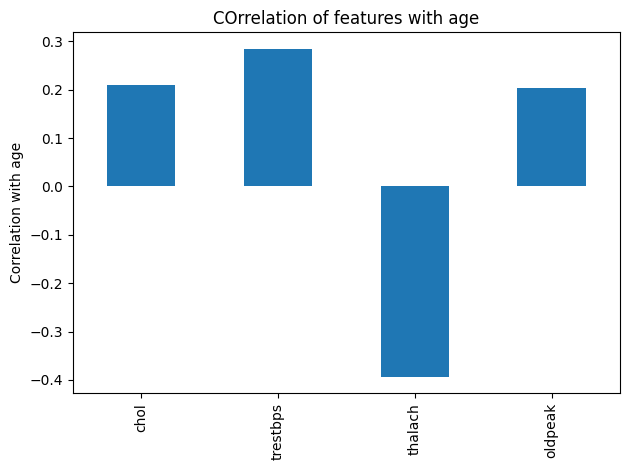

In [122]:
# Correlation with age
num_df = X[['age', 'chol', 'trestbps', 'thalach', 'oldpeak']].copy()
corr = num_df.corr(numeric_only=True)['age'].drop('age')

plt.figure()
corr.plot(kind='bar')
plt.ylabel('Correlation with age')
plt.title('COrrelation of features with age')
plt.tight_layout()
plt.show()

## 4.Data Post-processing

### 4.1 Raw Dataset

In [123]:
TARGET = 'target'

raw_feature_cols = [c for c in raw.columns if c != TARGET]
K = len(raw_feature_cols)

X_all = raw[raw_feature_cols]
y_all = raw[TARGET]

In [124]:
print(numeric_cols)
print(categorical_cols)

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [125]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split

In [126]:
cat_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', MinMaxScaler())
])

num_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer([
    ('cat', cat_proc, numeric_cols),
    ('num', num_proc, categorical_cols)
])

raw_pipeline = Pipeline([
    ('preprocess', preprocess)
])

In [127]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, stratify=y_temp, random_state=42
)

In [128]:
X_raw_train = raw_pipeline.fit_transform(X_train)
X_raw_val = raw_pipeline.transform(X_val)
X_raw_test = raw_pipeline.transform(X_test)

hasattr(transformer, 'get_feature_names_out') Kiểm tra transformer có method get_feature_names_out() không.
- OneHotEncoder — có → vì nó tạo ra nhiều cột mới từ 1 cột gốc, cần lấy tên cột mới
- StandardScaler, Pipeline — có thể có hoặc không tùy version sklearn

In [129]:
# Get the feature names after preprocessing
preprocessed_feature_names = []

for name, transformer, columns in preprocess.transformers_:
    if hasattr(transformer, 'get_feature_names_out'):
        preprocessed_feature_names.extend(transformer.get_feature_names_out(columns))
    else:
        preprocessed_feature_names.extend(columns)

raw_pipeline.fit_transform() và .transform() trả về NumPy array, không phải DataFrame.

In [130]:
# Convert NumPy arrays to DataFrames
X_raw_train_df = pd.DataFrame(X_raw_train, columns=preprocessed_feature_names, index=X_train.index)
X_raw_val_df   = pd.DataFrame(X_raw_val,   columns=preprocessed_feature_names, index=X_val.index)
X_raw_test_df  = pd.DataFrame(X_raw_test,  columns=preprocessed_feature_names, index=X_test.index)

In [131]:
from pathlib import Path

In [132]:
out_dir = Path('Data/split')
out_dir.mkdir(parents=True, exist_ok=True)

pd.concat([X_raw_train_df, y_train.rename(TARGET)], axis=1).to_csv(out_dir/'raw_train.csv', index=False)
pd.concat([X_raw_val_df, y_val.rename(TARGET)], axis=1).to_csv(out_dir/'raw_val.csv', index=False)
pd.concat([X_raw_test_df, y_test.rename(TARGET)], axis=1).to_csv(out_dir/'raw_test.csv', index=False)

print('Saved RAW splits. K (RAW features) = ', K)

Saved RAW splits. K (RAW features) =  13


In [133]:
display(X_raw_train_df)

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
180,0.395833,0.283019,0.337900,0.725191,0.080645,0.68313,0.870169,-0.411196,1.022996,-0.696177,0.675060,-0.693262,1.178215
208,0.541667,0.339623,0.310502,0.641221,0.000000,0.68313,-1.184278,-0.411196,-0.981579,-0.696177,-0.958585,-0.693262,-0.883127
167,0.520833,0.358491,0.369863,0.671756,0.000000,-1.46385,-1.184278,2.431930,1.022996,1.436416,-0.958585,0.443310,-0.883127
105,0.520833,0.132075,0.417808,0.648855,0.000000,0.68313,-1.184278,-0.411196,-0.981579,-0.696177,-0.958585,-0.693262,1.178215
297,0.583333,0.433962,0.262557,0.396947,0.032258,-1.46385,0.870169,-0.411196,-0.981579,1.436416,0.675060,-0.693262,1.178215
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.687500,0.433962,0.611872,0.656489,0.193548,-1.46385,0.870169,-0.411196,1.022996,-0.696177,0.675060,-0.693262,-0.883127
136,0.854167,0.481132,0.109589,0.412214,0.419355,0.68313,0.870169,-0.411196,-0.981579,1.436416,2.308704,-0.693262,1.178215
2,0.791667,0.245283,0.235160,0.442748,0.419355,0.68313,0.870169,-0.411196,1.022996,1.436416,0.675060,1.579882,1.178215
189,0.833333,0.433962,0.292237,0.572519,0.322581,0.68313,-0.157055,-0.411196,1.022996,-0.696177,0.675060,2.716454,1.178215


In [134]:
display(X_raw_train_df.isna().sum())

age         0
trestbps    0
chol        0
thalach     0
oldpeak     0
sex         0
cp          0
fbs         0
restecg     0
exang       0
slope       0
ca          0
thal        0
dtype: int64

### 4.2 Feature Engineering Dataset

In [135]:
def add_new_features(Xdf):
    Xdf = Xdf.copy()
    if set(['chol', 'age']).issubset(Xdf.columns):
        Xdf['chol_per_age'] = Xdf['chol']/Xdf['age']
    if set(['trestbps', 'age']).issubset(Xdf.columns):
        Xdf['bps_per_age'] = Xdf['trestbps']/Xdf['age']
    if set(['thalach', 'age']).issubset(Xdf.columns):
        Xdf['hr_ratio'] = Xdf['thalach']/Xdf['age']
    if set(['oldpeak', 'age']).issubset(Xdf.columns):
        Xdf['oldpeak_per_age'] = Xdf['oldpeak']/Xdf['age']
    if 'age' in Xdf.columns:
        Xdf['age_bin'] = pd.cut(Xdf['age'], bins=5, labels=False).astype('category')
    return Xdf

In [136]:
generated_cats = ['age_bin']
generated_nums = ['chol_per_age', 'bps_per_age', 'hr_ratio', 'oldpeak_per_age']
all_cats = categorical_cols + generated_cats
all_nums = numeric_cols + generated_nums

In [137]:
from sklearn.feature_selection import VarianceThreshold

In [138]:
cat_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

num_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer([
    ('cat', cat_proc, all_cats),
    ('num', num_proc, all_nums)
])

feature_adder = FunctionTransformer(add_new_features, validate=False)

fe_pipeline=Pipeline([
    ('add_feature', feature_adder),
    ('preprocess', preprocess),
    ('var_filter', VarianceThreshold())
])

In [145]:
Xt_train_np = fe_pipeline.fit_transform(X_train, y_train)
Xt_val_np = fe_pipeline.transform(X_val)
Xt_test_np = fe_pipeline.transform(X_test)

In [155]:
ohe = fe_pipeline.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
cat_names = []

for col, cats in zip(all_cats, ohe.categories_):
    for c in cats:
        cat_names.append(f'{col}_{c}')

pre_names = list(all_nums) + cat_names
mask = fe_pipeline.named_steps['var_filter'].get_support()
eng_cols = [name for name, keep in zip(pre_names, mask) if keep]

In [157]:
Xt_train = pd.DataFrame(Xt_train_np, columns=eng_cols, index=X_train.index)
Xt_val = pd.DataFrame(Xt_val_np, columns=eng_cols, index=X_val.index)
Xt_test = pd.DataFrame(Xt_test_np, columns=eng_cols, index=X_test.index)

In [158]:
is_discrete = np.array([col.startswith('age_bin_')
                        or any(col.startswith(pfx) for pfx in ['sex_','cp_','fbs_','restecg_','exang_','slope_','ca_','thal_'])
                        for col in Xt_train.columns], dtype=bool)

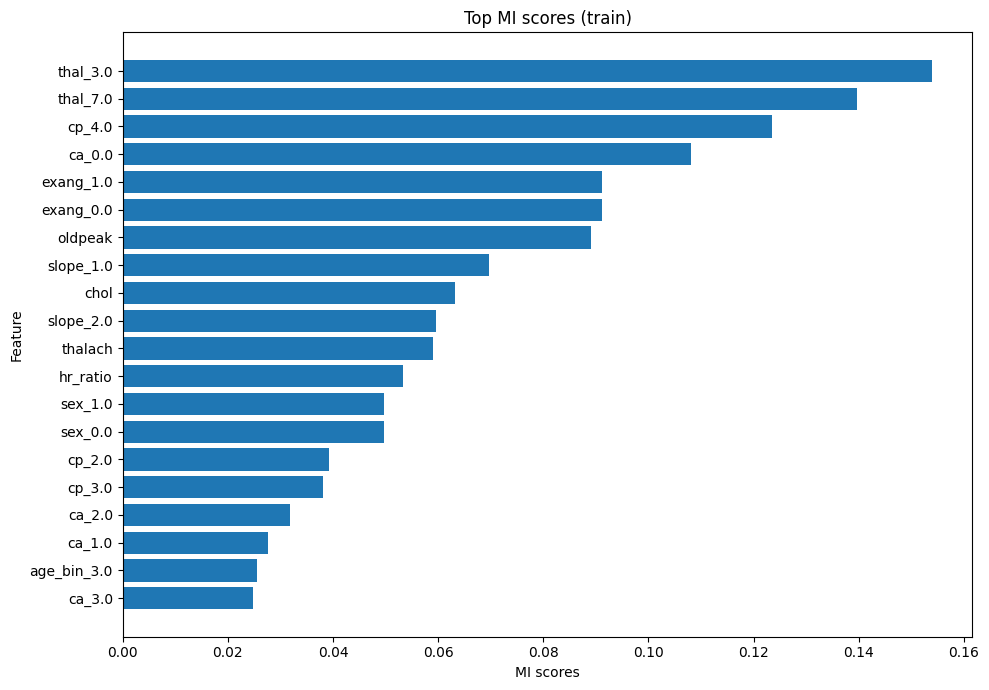

In [ ]:
mi_scores = mutual_info_classif(Xt_train.values, y_train.values, discrete_features=is_discrete, random_state=42)
mi_series = pd.Series(mi_scores, index=Xt_train.columns).sort_values(ascending=False)

# Visualize Top MI
topN = int(min(20, len(mi_series)))
top_mi = mi_series.head(topN).iloc[::-1] # Tại sao đảo ngược? Vì barh() vẽ từ dưới lên

plt.figure(figsize=(10, max(6, 0.35*topN)))
plt.barh(top_mi.index, top_mi.values)
plt.title('Top MI scores (train)')
plt.xlabel('MI scores')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
K = len([c for c in raw.columns if c != 'target'])
topk_cols = list(mi_series.head(K).index)

print("Selected TOP-K engineered features (K = RAW features):", K)
display(pd.Series(topk_cols, name="fe_topk_features").reset_index(drop=True))

fe_tr = Xt_train[topk_cols].copy()
fe_tr['target'] = y_train.values
fe_va = Xt_val[topk_cols].copy()
fe_va['target'] = y_val.values
fe_te = Xt_test[topk_cols].copy()
fe_te['target'] = y_test.values

Selected TOP-K engineered features (K = RAW features): 13


0      thal_3.0
1      thal_7.0
2        cp_4.0
3        ca_0.0
4     exang_1.0
5     exang_0.0
6       oldpeak
7     slope_1.0
8          chol
9     slope_2.0
10      thalach
11     hr_ratio
12      sex_1.0
Name: fe_topk_features, dtype: str

In [163]:
out_dir = Path('Data/split')
out_dir.mkdir(parents=True, exist_ok=True)
fe_tr.to_csv(out_dir/'fe_train.csv', index=False)
fe_va.to_csv(out_dir/'fe_val.csv',   index=False)
fe_te.to_csv(out_dir/'fe_test.csv',  index=False)

print("Saved FE splits. K (FE features) =", K)

Saved FE splits. K (FE features) = 13


In [164]:
display(fe_tr.head())
display(fe_tr.isna().sum())

,thal_3.0,thal_7.0,cp_4.0,ca_0.0,exang_1.0,exang_0.0,oldpeak,slope_1.0,chol,slope_2.0,thalach,hr_ratio,sex_1.0,target
180,0.0,1.0,1.0,1.0,0.0,1.0,-0.445445,0.0,0.458139,1.0,0.708371,0.726265,1.0,1
208,1.0,0.0,0.0,1.0,0.0,1.0,-0.891627,1.0,0.230598,0.0,0.222495,-0.054469,1.0,0
167,1.0,0.0,0.0,0.0,1.0,0.0,-0.891627,1.0,0.723605,0.0,0.399178,0.099522,0.0,0
105,0.0,1.0,0.0,1.0,0.0,1.0,-0.891627,1.0,1.121803,0.0,0.266666,0.031766,1.0,0
297,0.0,1.0,1.0,1.0,1.0,0.0,-0.713154,0.0,-0.167601,1.0,-1.190962,-0.859761,0.0,1


thal_3.0     0
thal_7.0     0
cp_4.0       0
ca_0.0       0
exang_1.0    0
exang_0.0    0
oldpeak      0
slope_1.0    0
chol         0
slope_2.0    0
thalach      0
hr_ratio     0
sex_1.0      0
target       0
dtype: int64

In [166]:
# zip folder
!zip -r dataset.zip Data/split

  adding: Data/split/ (stored 0%)
  adding: Data/split/raw_train.csv (deflated 91%)
  adding: Data/split/raw_test.csv (deflated 82%)
  adding: Data/split/raw_val.csv (deflated 83%)
  adding: Data/split/fe_val.csv (deflated 64%)
  adding: Data/split/fe_train.csv (deflated 74%)
  adding: Data/split/fe_test.csv (deflated 64%)
